# Simple KI-Mdell for classification of sonar data

## Einstellungen

In [94]:
# Imports

import pandas as pd
import os

import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import pickle
import os

In [95]:
# Configs

# Daten
base_path = os.path.abspath(os.path.join(os.getcwd(), '../../../data/messung_08_01_26'))
files = [
    'Sand_training_data.csv',
    'Gravel_training_data.csv',
    'Stones_training_data.csv'
]

# Model
MAX_DEPTH = 4
save_model = False
model_save_path = os.path.abspath(os.path.join(os.getcwd(), "../../models/sonar_model_v2.pkl"))


## Trainingsdaten laden

In [96]:
# Daten einlesen
data_frames = []
for file in files:
    file_path = os.path.join(base_path, file)
    df = pd.read_csv(file_path, sep=';')                # Einlesen der CSV-Dateien, Trennzeichen ist Semikolon
    data_frames.append(df)

# Zusammenfügen zu einem einzigen DataFrame
data_frame = pd.concat(data_frames, ignore_index=True)

# Filtern der Spalten: Wir wollen 'class_name', 'Frequency' und alle 'S_...' Spalten
amplitude_cols = [col for col in data_frame.columns if col.startswith('S_')]               # Identifizieren der Spalten, die mit 'S_' beginnen
selected_cols = ['class_name', 'Frequency'] + amplitude_cols                        # Auswahl der gewünschten Spalten
data_frame = data_frame[selected_cols]

# Anzeigen der ersten Zeilen und der Größe des DataFrames
print(f"Form des DataFrames: {data_frame.shape}")
display(data_frame.head())

Form des DataFrames: (108, 402)


,class_name,Frequency,S_0,S_1,S_2,S_3,S_4,S_5,S_6,S_7,...,S_390,S_391,S_392,S_393,S_394,S_395,S_396,S_397,S_398,S_399
0,Sand,low,136,200,226,255,260,250,242,239,...,85.0,90.0,94.0,98.0,98.0,92.0,90.0,91.0,99.0,104.0
1,Sand,high,448,358,583,996,1002,1039,2206,3412,...,41.0,47.0,52.0,49.0,52.0,54.0,49.0,41.0,42.0,48.0
2,Sand,low,136,201,225,255,261,251,242,239,...,159.0,151.0,141.0,137.0,132.0,133.0,131.0,133.0,131.0,118.0
3,Sand,high,454,365,592,963,958,1200,2544,3785,...,43.0,33.0,26.0,21.0,21.0,21.0,22.0,23.0,22.0,19.0
4,Sand,low,136,201,228,256,261,251,243,239,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Ausgabe vo 20 Zeitreihen pro klasse in ein Diagramm

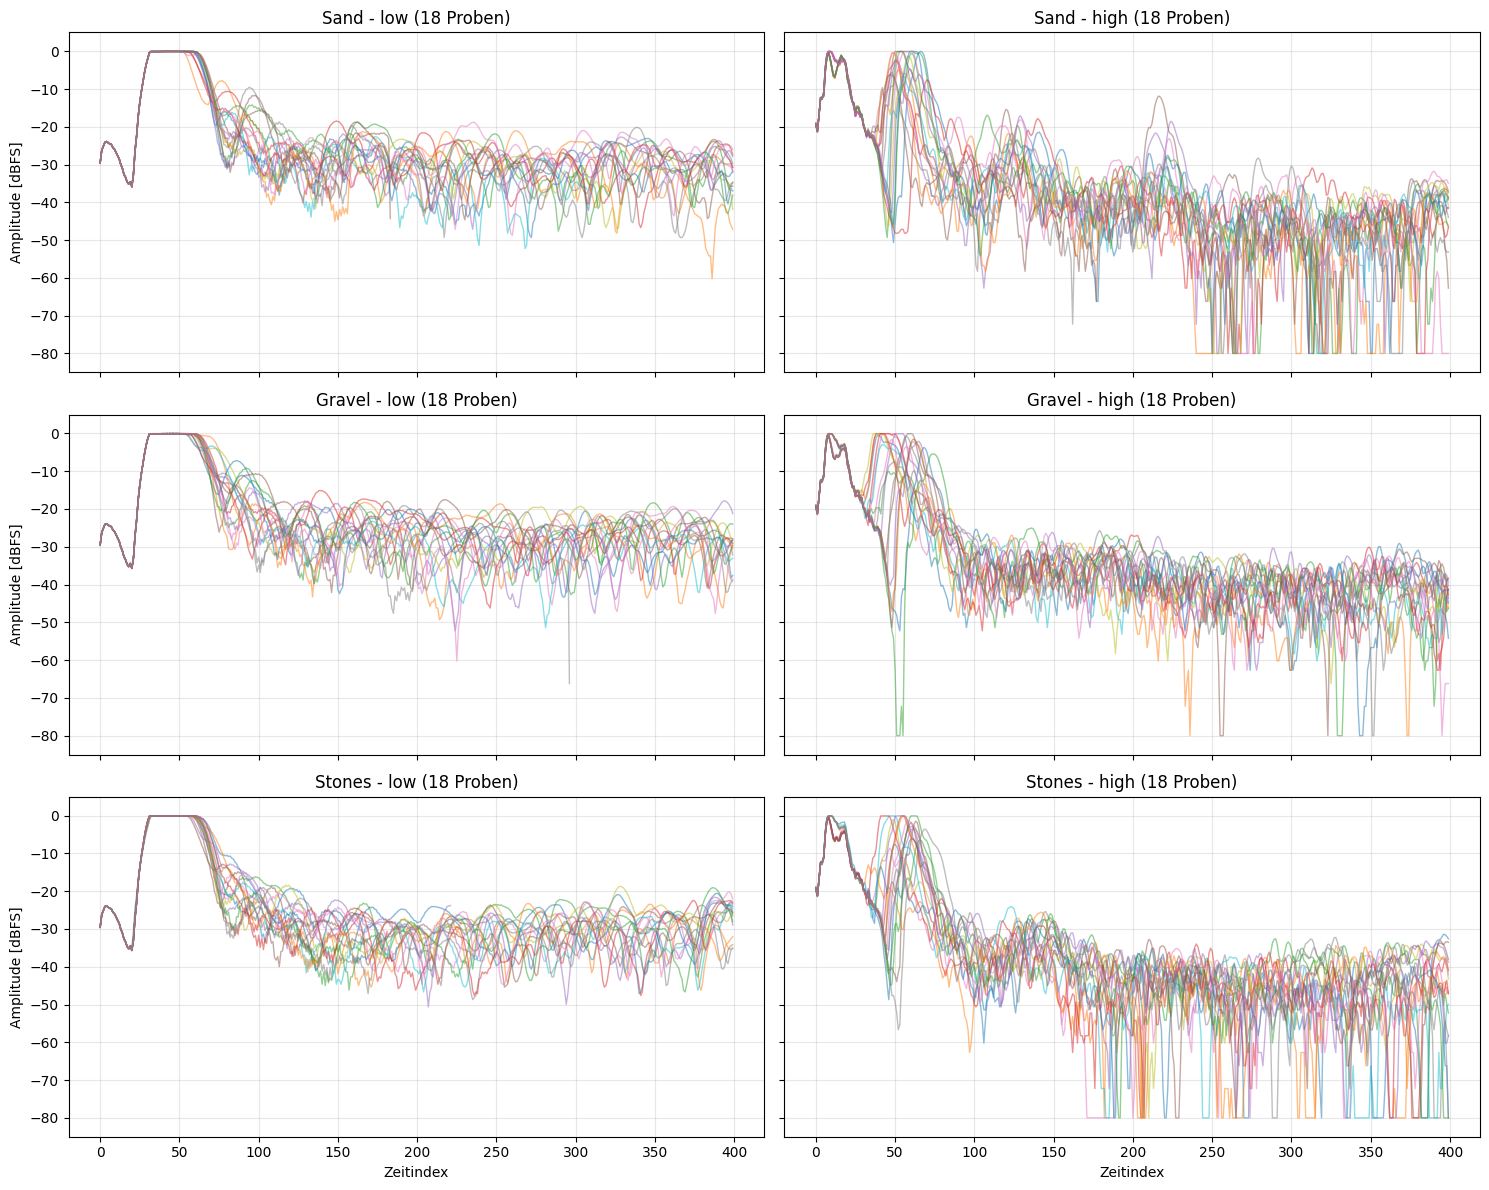

In [97]:
# Eindeutige Klassen finden
classes = ['Sand', 'Gravel', 'Stones']
frequencies = ['low', 'high']  # Definierte Reihenfolge

num_classes = len(classes)
num_freqs = len(frequencies)

# Subplots erstellen: Zeilen = Klassen, Spalten = Frequenzen
# sharey='row' sorgt dafür, dass die Y-Achsen innerhalb einer Klasse vergleichbar sind
fig, axes = plt.subplots(num_classes, num_freqs, figsize=(15, 4*num_classes), sharex=True, sharey='row')

# Wenn es nur eine Klasse gibt, ist axes ein 1D Array, wir machen es 2D für konsistente Indizierung
if num_classes == 1:
    axes = np.array([axes])

for i, class_name in enumerate(classes):
    for j, freq in enumerate(frequencies):
        ax = axes[i, j]
        
        # Daten filtern für spezifische Klasse und Frequenz
        subset = data_frame[(data_frame['class_name'] == class_name) & (data_frame['Frequency'] == freq)]
        
        n_samples = min(20, len(subset))
        
        if n_samples > 0:
            # Zufällige Auswahl
            sampled_data = subset.sample(n_samples, random_state=42)
            
            # --- START ÄNDERUNG ---
            # 1. Rohdaten holen (als Float)
            result = sampled_data.drop(columns=['class_name', 'Frequency']).values.astype(float)
            
            # 2. Direkt in dB umrechnen (Vektiorisiert für alle Zeilen gleichzeitig)
            # Normalisieren (/4095), Logarithmieren (20*log10) und Clippen (min -80dB)
            amplitudes = np.clip(20 * np.log10(np.clip(result / 4095.0, 1e-9, 1.0)), -80, 0)
            
            # Plotten
            for row in amplitudes:
                ax.plot(row, alpha=0.5, linewidth=1)
                
            # Y-Achse fixieren (-85 bis 5 dB)
            ax.set_ylim(-85, 5)
            # --- ENDE ÄNDERUNG ---
            ax.set_title(f'{class_name} - {freq} ({n_samples} Proben)')
        else:
            ax.set_title(f'{class_name} - {freq} (Keine Daten)')
        
        ax.grid(True, alpha=0.3)
        
        # Y-Label nur in der ersten Spalte
        if j == 0:
            ax.set_ylabel('Amplitude [dBFS]')
        
        # X-Label nur in der letzten Zeile
        if i == num_classes - 1:
            ax.set_xlabel('Zeitindex')

plt.tight_layout()
plt.show()

## Algorithmus zur Klassifikation 


### Datenvorbereitung


In [ ]:
df_high = data_frame[data_frame['Frequency'].str.lower() == 'high'].reset_index(drop=True)
df_low = data_frame[data_frame['Frequency'].str.lower() == 'low'].reset_index(drop=True)

# Amplituden für High und Low zusammenführen
amplitude_cols = [c for c in data_frame.columns if c.startswith('S_')]
feature_cols_high = [f"{c}_high" for c in amplitude_cols]
feature_cols_low = [f"{c}_low" for c in amplitude_cols]
feature_cols = feature_cols_high + feature_cols_low

# Zuerst das kombinierte DataFrame aufbauen
combined_df = pd.DataFrame()

# Spalten blockweise hinzufügen
combined_df['class_name'] = df_high['class_name'].values
combined_df[feature_cols_high] = df_high[amplitude_cols].values
combined_df[feature_cols_low] = df_low[amplitude_cols].values

print("Shape des kombinierten DataFrames:", combined_df.shape)
display(combined_df.head())

### Modell Definition 

In [99]:
# X und y aus dem kombinierten DataFrame auslesen
X = combined_df[feature_cols].values
y = combined_df['class_name'].values

print(f"\nFeature Matrix Shape: {X.shape} (Samples x Features)")

# Labels kodieren
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Random Forest Classifier erstellen
clf = RandomForestClassifier(n_estimators=100, max_depth=MAX_DEPTH, random_state=42)



Feature Matrix Shape: (54, 800) (Samples x Features)


### Training 

In [100]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print("Trainingsdaten Shape:", X_train.shape)
print("Testdaten Shape:", X_test.shape)

# Modell trainieren
clf.fit(X_train, y_train)

# Modell Evaluation AUSSCHLIESSLICH auf dem Testdatensatz
y_pred = clf.predict(X_test)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Trainingsdaten Shape: (43, 800)
Testdaten Shape: (11, 800)

Classification Report (Test Set):
              precision    recall  f1-score   support

      Gravel       1.00      1.00      1.00         3
        Sand       1.00      1.00      1.00         4
      Stones       1.00      1.00      1.00         4

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



#### Bewertung

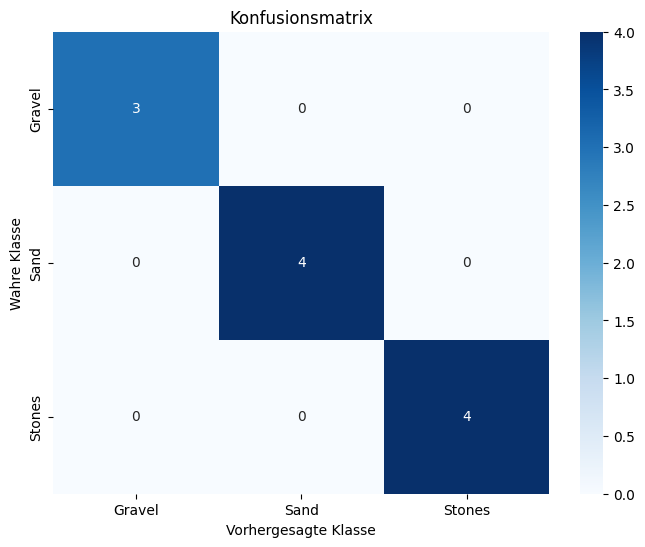

In [101]:
# A) Konfusionsmatrix

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Wahre Klasse')
plt.xlabel('Vorhergesagte Klasse')
plt.title('Konfusionsmatrix')
plt.show()


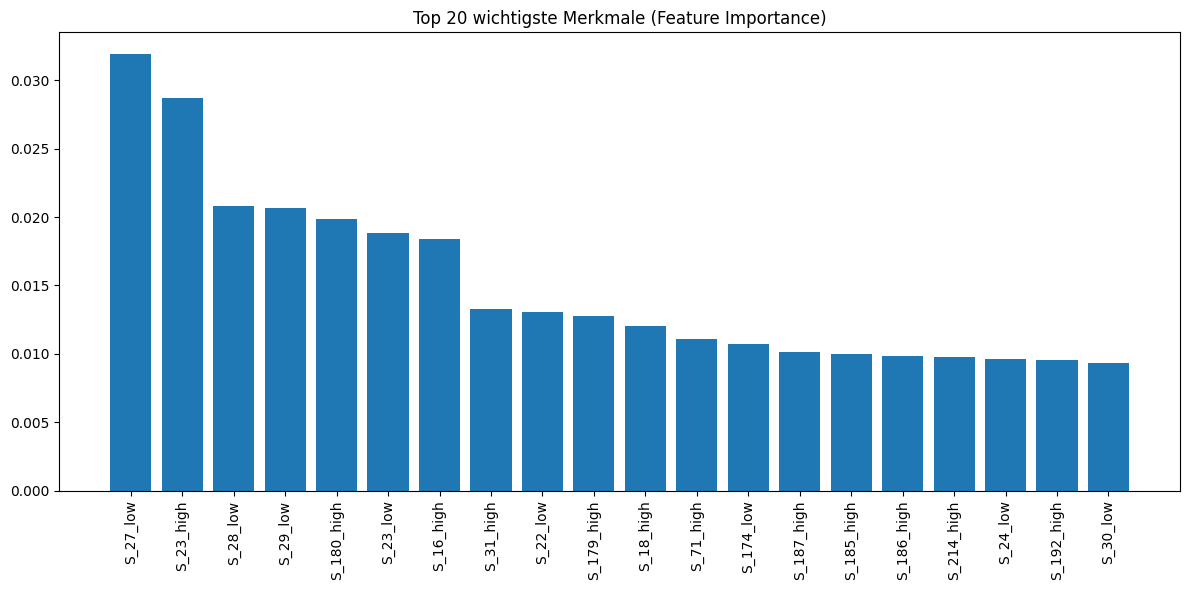

In [102]:
# B) Feature Importance (Was ist wichtig?)

importances = clf.feature_importances_
indices = np.argsort(importances)[::-1][:20] # Top 20

plt.figure(figsize=(12, 6))
plt.title("Top 20 wichtigste Merkmale (Feature Importance)")
plt.bar(range(20), importances[indices], align="center")
plt.xticks(range(20), [feature_cols[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()



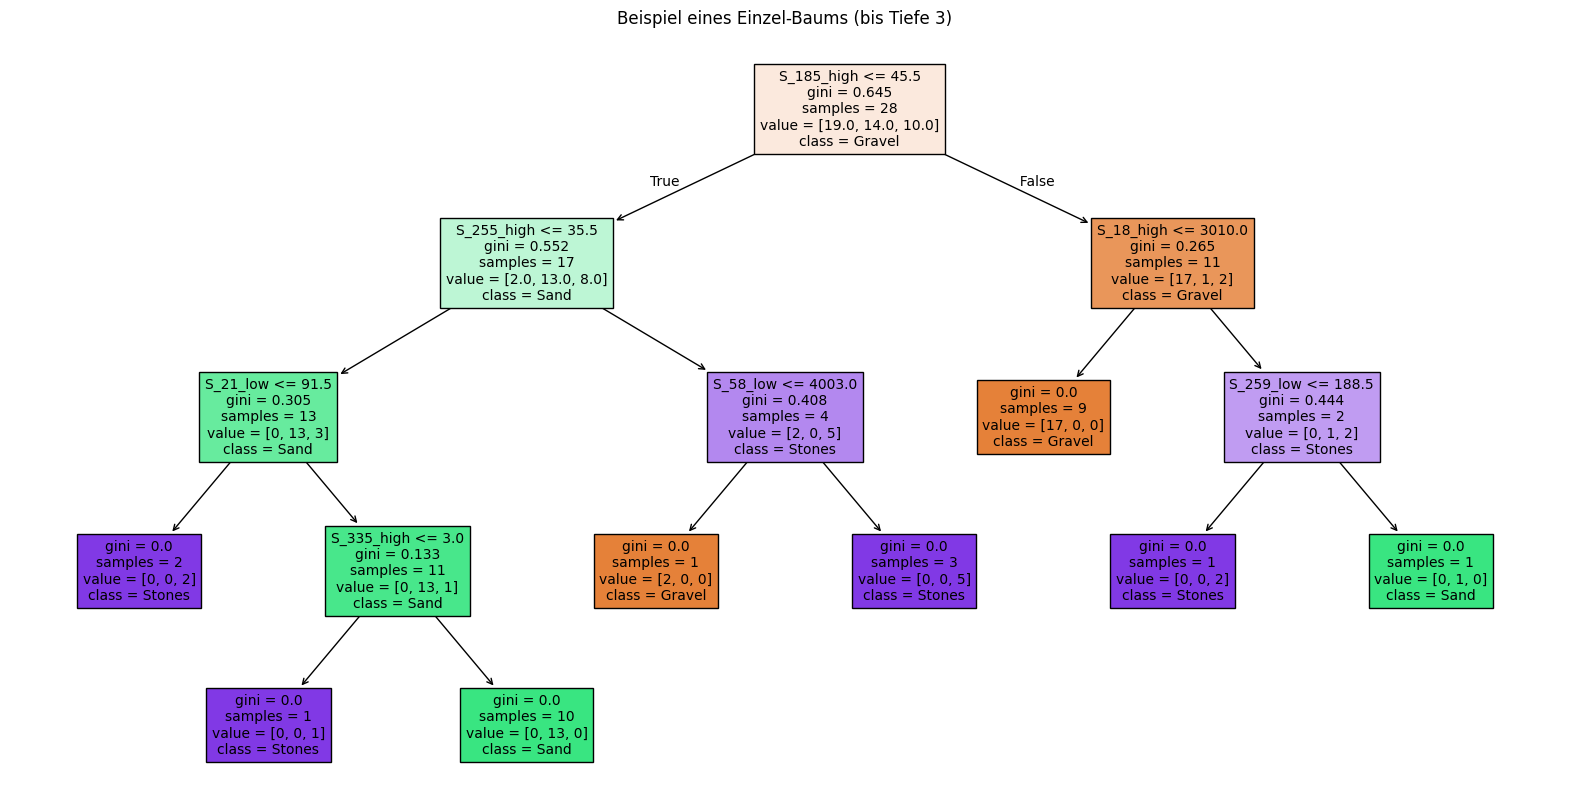

In [103]:
# C) Entscheidungsbaum visualisieren (Einer aus dem Wald)

plt.figure(figsize=(20, 10))
# Wir begrenzen die Tiefe in der Grafik, damit man noch etwas lesen kann
plot_tree(clf.estimators_[0], feature_names=feature_cols, class_names=le.classes_, filled=True, max_depth=MAX_DEPTH , fontsize=10)
plt.title("Beispiel eines Einzel-Baums (bis Tiefe 3)")
plt.show()

### Speichern 

In [104]:
if save_model:
    # Ordner erstellen, falls er nicht existiert
    os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

    # Modell speichern
    with open(save_path, 'wb') as f:
        pickle.dump(clf, f)
    print(f"✅ Modell erfolgreich gespeichert: {model_save_path}")
else:
    print(f"Modell nicht gespeichert: {model_save_path}")
    

Modell nicht gespeichert: c:\Users\samso\OneDrive\Dokumente\Uni\Semester 9\sonar_mpa\dev\models\sonar_model_v2.pkl
